<a href="https://colab.research.google.com/github/Tirantha/Statistical-Learning-e22040/blob/main/computational%20practical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EM2050 Computational Methods
# E/22/040
# Practical 1 — Radar Tracking of an Airplane

# 1(a) Sketch of the Configuration

The radar stations A and B are separated by a horizontal distance:

$$
a = 500 \text{ m}
$$

The airplane is located at point $$C(x,y)$$.

- Angle $$\alpha$$ is measured from station A.
- Angle $$\beta$$ is measured from station B.



In [25]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-05-17 at 18.11.35.jpeg to WhatsApp Image 2026-05-17 at 18.11.35 (1).jpeg


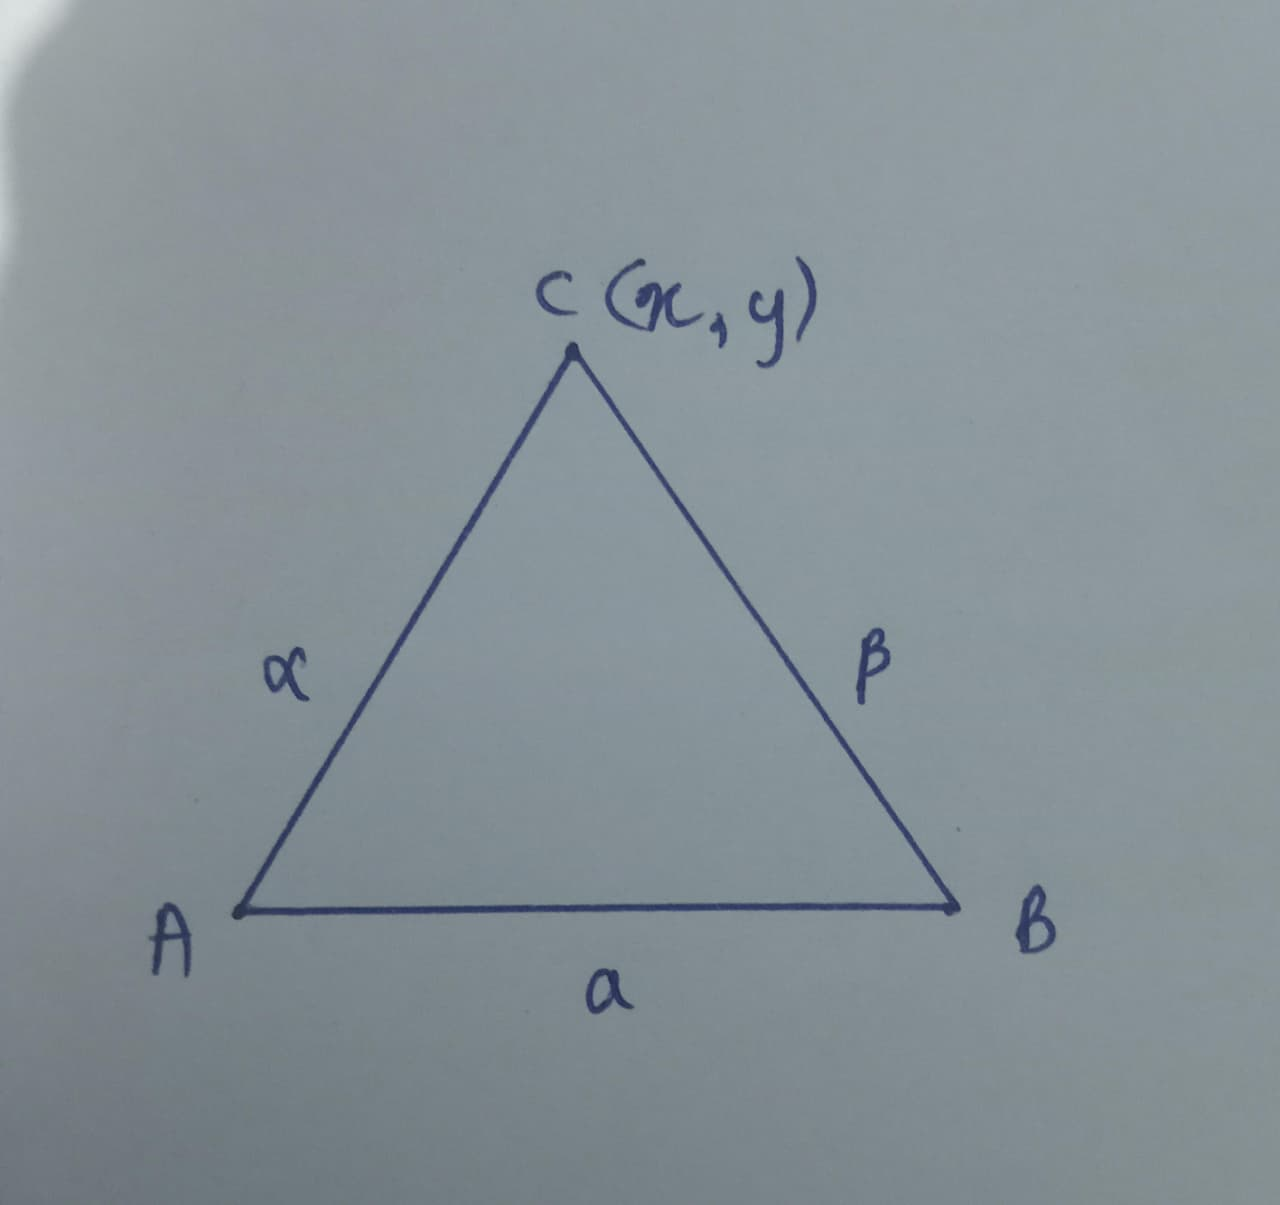

In [28]:
from IPython.display import Image, display

display(Image('WhatsApp Image 2026-05-17 at 18.11.35 (1).jpeg'))

# 1(b) Why $$ \tan\beta - \tan\alpha \neq 0 $$

The formulas are:

$$
x=\frac{a\tan\beta}{\tan\beta-\tan\alpha}
$$

$$
y=\frac{a\tan\beta\tan\alpha}{\tan\beta-\tan\alpha}
$$

If:

$$
\tan\beta = \tan\alpha
$$

then the denominator becomes zero.

Division by zero is undefined, so the airplane position cannot be computed.

Physically, this means the radar lines become parallel and do not intersect at a unique point.

# 2(c) Expected Speed Behaviour

The angles increase gradually over time.

- $$\alpha$$ increases from $$20^\circ$$ to $$22.5^\circ$$
- $$\beta$$ increases from $$45^\circ$$ to $$47.6^\circ$$

Since the changes are fairly smooth and uniform, the airplane speed is expected to remain approximately constant with a slight decrease near the end.

In [2]:
import numpy as np

In [3]:
plane = np.array([
    [7, 20.0, 45.0],
    [8, 20.5, 45.4],
    [9, 21.0, 45.8],
    [10, 21.4, 46.2],
    [11, 21.8, 46.6],
    [12, 22.1, 47.0],
    [13, 22.3, 47.3],
    [14, 22.5, 47.6]
])

print(plane)

[[ 7.  20.  45. ]
 [ 8.  20.5 45.4]
 [ 9.  21.  45.8]
 [10.  21.4 46.2]
 [11.  21.8 46.6]
 [12.  22.1 47. ]
 [13.  22.3 47.3]
 [14.  22.5 47.6]]


# 3(d) Convert Angles to Radians

The trigonometric formulas require radians instead of degrees.

NumPy function:

```python
np.deg2rad()
```

is used for the conversion.

In [18]:
t = plane[:,0]

alpha_deg = plane[:,1]
beta_deg = plane[:,2]

alpha = np.deg2rad(alpha_deg)
beta = np.deg2rad(beta_deg)

print(alpha)
print(beta)

[0.34906585 0.3577925  0.36651914 0.37350046 0.38048178 0.38571776
 0.38920842 0.39269908]
[0.78539816 0.79237948 0.7993608  0.80634211 0.81332343 0.82030475
 0.82554074 0.83077672]


# 3(e) Compute Coordinates

The airplane coordinates are computed using:

$$
x=\frac{a\tan\beta}{\tan\beta-\tan\alpha}
$$

$$
y=\frac{a\tan\beta\tan\alpha}{\tan\beta-\tan\alpha}
$$

In [19]:
a = 500

x = a*np.tan(beta)/(np.tan(beta)-np.tan(alpha))

y = a*np.tan(beta)*np.tan(alpha)/(np.tan(beta)-np.tan(alpha))

for i in range(len(t)):
    print(f"t={t[i]:.0f}, x={x[i]:.2f}, y={y[i]:.2f}")

t=7, x=786.13, y=286.13
t=8, x=792.02, y=296.12
t=9, x=797.82, y=306.25
t=10, x=801.04, y=313.93
t=11, x=804.16, y=321.64
t=12, x=804.71, y=326.76
t=13, x=804.45, y=329.93
t=14, x=804.15, y=333.09


# 4(f) Numerical Differentiation

Time step:

$$
h=1 \text{ s}
$$

The derivatives are approximated using:

## Forward Difference

$$
f'(t_0)\approx\frac{f(t_1)-f(t_0)}{h}
$$

## Centered Difference

$$
f'(t_i)\approx\frac{f(t_{i+1})-f(t_{i-1})}{2h}
$$

## Backward Difference

$$
f'(t_n)\approx\frac{f(t_n)-f(t_{n-1})}{h}
$$

In [20]:
h = 1

xprime = np.zeros(len(x))
yprime = np.zeros(len(y))

# Forward difference
xprime[0] = (x[1]-x[0])/h
yprime[0] = (y[1]-y[0])/h

# Centered differences
for i in range(1, len(x)-1):
    xprime[i] = (x[i+1]-x[i-1])/(2*h)
    yprime[i] = (y[i+1]-y[i-1])/(2*h)

# Backward difference
xprime[-1] = (x[-1]-x[-2])/h
yprime[-1] = (y[-1]-y[-2])/h

for i in range(len(t)):
    print(f"t={t[i]:.0f}, x'={xprime[i]:.2f}, y'={yprime[i]:.2f}")

t=7, x'=5.89, y'=10.00
t=8, x'=5.85, y'=10.06
t=9, x'=4.51, y'=8.90
t=10, x'=3.17, y'=7.69
t=11, x'=1.83, y'=6.42
t=12, x'=0.14, y'=4.14
t=13, x'=-0.28, y'=3.17
t=14, x'=-0.30, y'=3.16


# 4(g) Why Centered Differences Cannot Be Used at Endpoints

Centered differences require values on both sides of a point:

$$
f'(t_i)\approx\frac{f(t_{i+1})-f(t_{i-1})}{2h}
$$

At \(t=7\), there is no previous value.

At \(t=14\), there is no next value.

Therefore centered differences cannot be used at the endpoints.

Centered differences are second-order accurate:

$$
O(h^2)
$$

Forward and backward differences are first-order accurate:

$$
O(h)
$$

So accuracy is reduced at the endpoints.

# 5(h) Compute Speed

The speed is:

$$
v(t)=\sqrt{(x'(t))^2+(y'(t))^2}
$$

In [21]:
v = np.sqrt(xprime**2 + yprime**2)

for i in range(len(t)):
    print(f"t={t[i]:.0f}, speed={v[i]:.2f} m/s")

t=7, speed=11.60 m/s
t=8, speed=11.64 m/s
t=9, speed=9.98 m/s
t=10, speed=8.32 m/s
t=11, speed=6.67 m/s
t=12, speed=4.15 m/s
t=13, speed=3.18 m/s
t=14, speed=3.18 m/s


# 5(i) Largest Decrease in Speed

In [22]:
speed_drop = np.diff(v)

print(speed_drop)

index = np.argmin(speed_drop)

print("\nLargest decrease occurs between:")
print(f"t={t[index]} and t={t[index+1]}")

[ 0.03590855 -1.65825498 -1.65856297 -1.64970436 -2.52586075 -0.96689782
 -0.0025724 ]

Largest decrease occurs between:
t=11.0 and t=12.0


# 6(j) Sensitivity to Measurement Noise

The speed \(v(t)\) is more sensitive to measurement noise than the position.

This is because speed is computed using numerical differentiation.

Differentiation amplifies small measurement errors and fluctuations in the data.

# 6(k) Effect of Recording Every 2 Seconds

If measurements are recorded every 2 seconds instead of every 1 second:

- The time step \(h\) becomes larger.
- Numerical differentiation becomes less accurate.
- Approximation errors increase.

Finite difference errors depend on powers of \(h\):

- First-order error: $$O(h)$$
- Second-order error: $$O(h^2)$$

Therefore increasing the step size reduces the accuracy of the computed speed.